In [1]:
# ============================================================
# IMPORTS NECESARIOS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix,classification_report,roc_curve,roc_auc_score,precision_recall_curve,auc)

from google.colab import files

In [2]:
# Subir archivo

uploaded = files.upload()
for fn in uploaded.keys():
    print('Archivo cargado:', fn)
    df = pd.read_csv(fn)


Saving Titanic-Dataset.csv to Titanic-Dataset.csv
Archivo cargado: Titanic-Dataset.csv


In [3]:
# ============================================================
# Exploración y comprensión del dataset
# ============================================================

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# Detectar valores faltantes

df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
# Revisar desbalanceo de clases

df['Survived'].value_counts(normalize=True)


,proportion
Survived,
0,0.616162
1,0.383838


In [6]:
# ============================================================
# Preprocesamiento
# ============================================================

# Variables
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch']
categorical_features = ['Sex', 'Embarked', 'Pclass']

# Imputación numérica y codificación categórica
num_imputer = SimpleImputer(strategy='median')
cat_encoder = OneHotEncoder(drop='first')

# Escalado
scaler = StandardScaler()

# Pipeline de preprocesamiento
preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', num_imputer), ('scaler', scaler)]), numerical_features),
    ('cat', cat_encoder, categorical_features)
])

In [7]:
# ============================================================
# División Train/Test
# ============================================================

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
# ============================================================
# Construcción del modelo
# ============================================================

# Modelo con regularización L2 (por defecto)
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

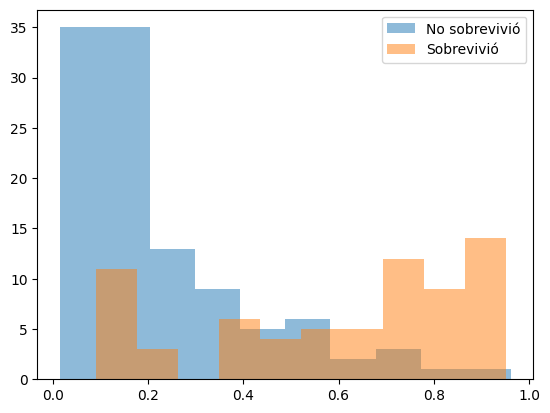

In [9]:
# ============================================================
# Entrenamiento y predicción inicial
# ============================================================

# Entrenamiento
model.fit(X_train, y_train)

# Probabilidades
y_prob = model.predict_proba(X_test)[:,1]

# Predicción inicial (umbral 0.5)
y_pred = (y_prob >= 0.5).astype(int)

# Distribución de probabilidades
plt.hist(y_prob[y_test==0], alpha=0.5, label='No sobrevivió')
plt.hist(y_prob[y_test==1], alpha=0.5, label='Sobrevivió')
plt.legend()
plt.show()

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

[[98 12]
 [23 46]]


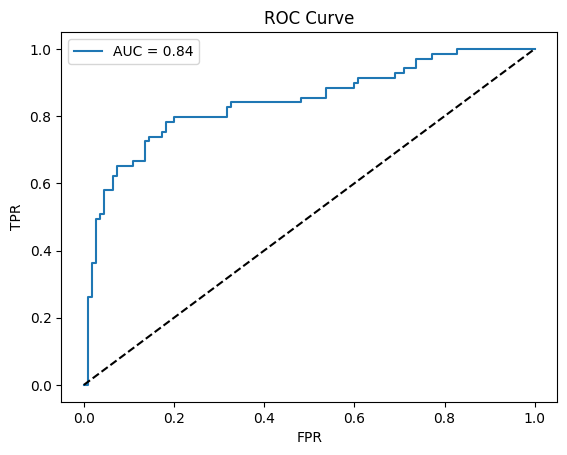

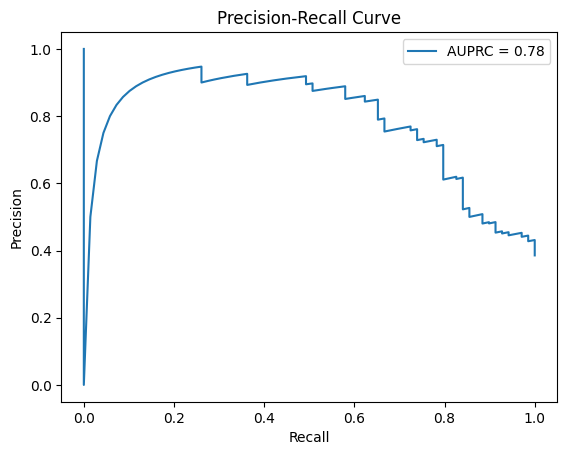

In [10]:
# ============================================================
# Evaluación
# ============================================================

print(classification_report(y_test, y_pred))

# Matriz de confusión
print(confusion_matrix(y_test, y_pred))

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Precision-Recall
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
plt.plot(recall, precision, label=f'AUPRC = {pr_auc:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


In [11]:
# ============================================================
# Ajuste del umbral
# ============================================================

# Cambiar umbral
import numpy as np
threshold = 0.4
y_pred_new = (y_prob >= threshold).astype(int)
print(classification_report(y_test, y_pred_new))


              precision    recall  f1-score   support

           0       0.84      0.85      0.85       110
           1       0.76      0.74      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [12]:
# ============================================================
# Interpretación de coeficientes
# ============================================================

coefficients = model.named_steps['classifier'].coef_[0]
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df.sort_values(by='Coefficient', ascending=False)


,Feature,Coefficient
5,cat__Embarked_Q,0.236477
7,cat__Embarked_nan,0.177340
1,num__Fare,0.172493
3,num__Parch,-0.068307
2,num__SibSp,-0.260174
6,cat__Embarked_S,-0.446312
0,num__Age,-0.471231
8,cat__Pclass_2,-0.731470
9,cat__Pclass_3,-1.921663
4,cat__Sex_male,-2.524709
